**Can machine learning identify customers who are most likely to respond positively to a bank marketing campaign?**

Using the Bank Market data set we are going to try and predict which customer wil most likely respond to marketing to help determineing which customers to call.

This will enable the Sales and Marketing teams to more effectively target customers who are most likely to respond, ultimately increasing revenue through higher conversion rates while reducing time spent following up with unresponsive customers.


In [67]:
#import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno



In [68]:
#Load the dataset
df = pd.read_csv(r'C:\Users\Tech\Documents\Bank Marketing\bank-full data.csv')

In [69]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [70]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


Let's get the meanings of our columns so that we can understand what we are working with.
- age - numerical
- job : type of job (categorical: "admin.","unknown","unemployed","management","housemaid","entrepreneur","student","blue-collar","self-employed","retired","technician","services")
- marital : marital status (categorical: "married","divorced","single"; note: "divorced" means divorced or widowed)
- education (categorical: "unknown","secondary","primary","tertiary")
- default: has credit in default? (binary: "yes","no")
- balance: average yearly balance, in euros (numeric)
- housing: has housing loan? (binary: "yes","no")
- loan: has personal loan? (binary: "yes","no")
- contact: contact communication type (categorical: "unknown","telephone","cellular")
- day: last contact day of the month (numeric)
- month: last contact month of year (categorical: "jan", "feb", "mar", ..., "nov", "dec")
- duration: last contact duration, in seconds (numeric)
- campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
- pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric, -1 means client was not previously contacted)
- previous: number of contacts performed before this campaign and for this client (numeric)
- poutcome: outcome of the previous marketing campaign (categorical: "unknown","other","failure","success")
- y - has the client subscribed a term deposit? (binary: "yes","no")



In [71]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='str')

In [73]:
#Change the column names to make is easier to work with
df.columns = [
    'age',
    'employment_type',
    'marital_status',
    'education',
    'credit_default',
    'average_yearly_balance',
    'housing_loan',
    'personal_loan',
    'contact_type',
    'last_contact_day',
    'last_contact_month',
    'last_contact_duration',
    'campaign_contacts',
    'days_since_last_campaign_contact',
    'previous_contacts_before_campaign',
    'previous_outcome',
    'subscribed_to_term_deposit'
    ]

In [74]:
df.tail()

,age,employment_type,marital_status,education,credit_default,average_yearly_balance,housing_loan,personal_loan,contact_type,last_contact_day,last_contact_month,last_contact_duration,campaign_contacts,days_since_last_campaign_contact,previous_contacts_before_campaign,previous_outcome,subscribed_to_term_deposit
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no
45210,37,entrepreneur,married,secondary,no,2971,no,no,cellular,17,nov,361,2,188,11,other,no


Performing EDA to understand our data better.

In [75]:
#check to see how imbalanced our target variable is
df["subscribed_to_term_deposit"].value_counts(normalize=True) * 100

subscribed_to_term_deposit
no     88.30152
yes    11.69848
Name: proportion, dtype: float64

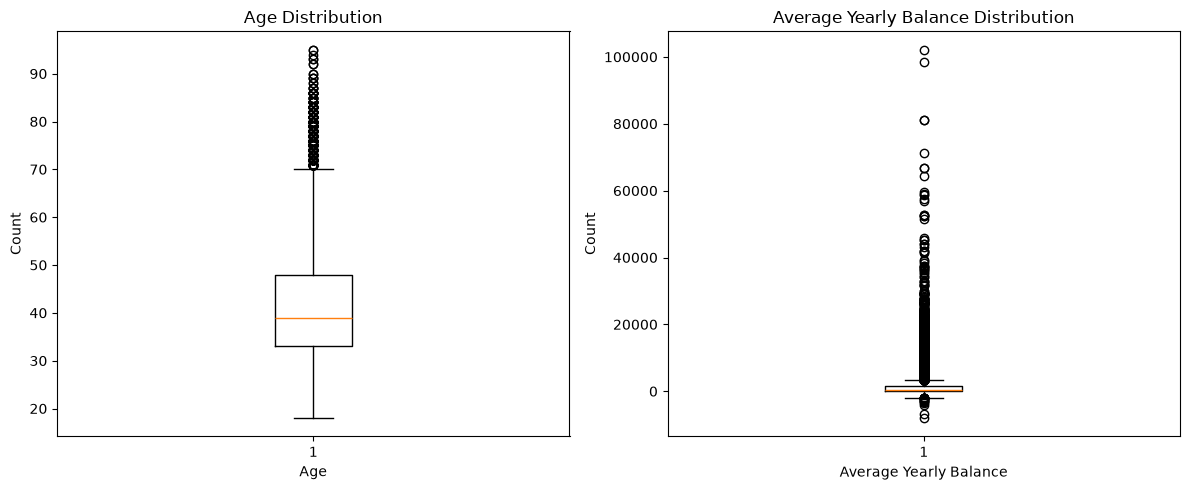

In [76]:
#Check the distribution of age and average yearly balance using boxplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Age
axes[0].boxplot(df["age"], label=["Age"])
axes[0].set_title("Age Distribution")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Count")

# Average yearly balance
axes[1].boxplot(df["average_yearly_balance"], label=["Average Yearly Balance"])
axes[1].set_title("Average Yearly Balance Distribution")
axes[1].set_xlabel("Average Yearly Balance")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

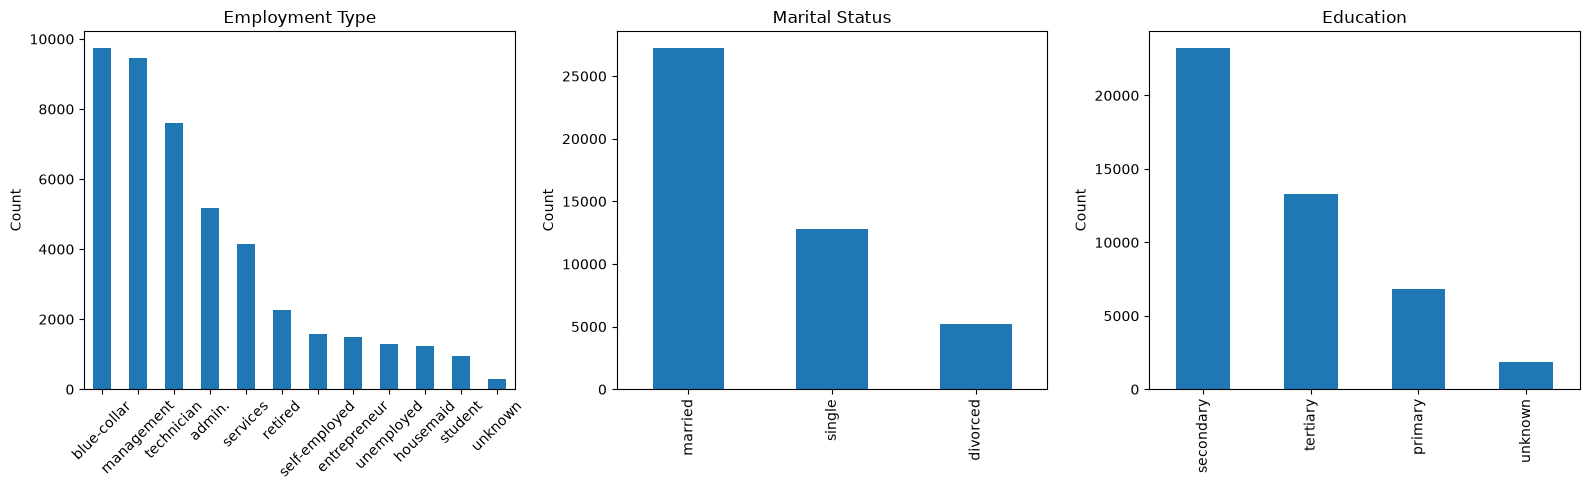

In [77]:
#Check the distribution of categorical variables using bar plots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Employment
df["employment_type"].value_counts().plot(
    kind="bar", ax=axes[0]
)
axes[0].set_title("Employment Type")
axes[0].set_xlabel("")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

# Marital status
df["marital_status"].value_counts().plot(
    kind="bar", ax=axes[1]
)
axes[1].set_title("Marital Status")
axes[1].set_xlabel("")
axes[1].set_ylabel("Count")

# Education
df["education"].value_counts().plot(
    kind="bar", ax=axes[2]
)
axes[2].set_title("Education")
axes[2].set_xlabel("")
axes[2].set_ylabel("Count")

plt.tight_layout()
plt.show()

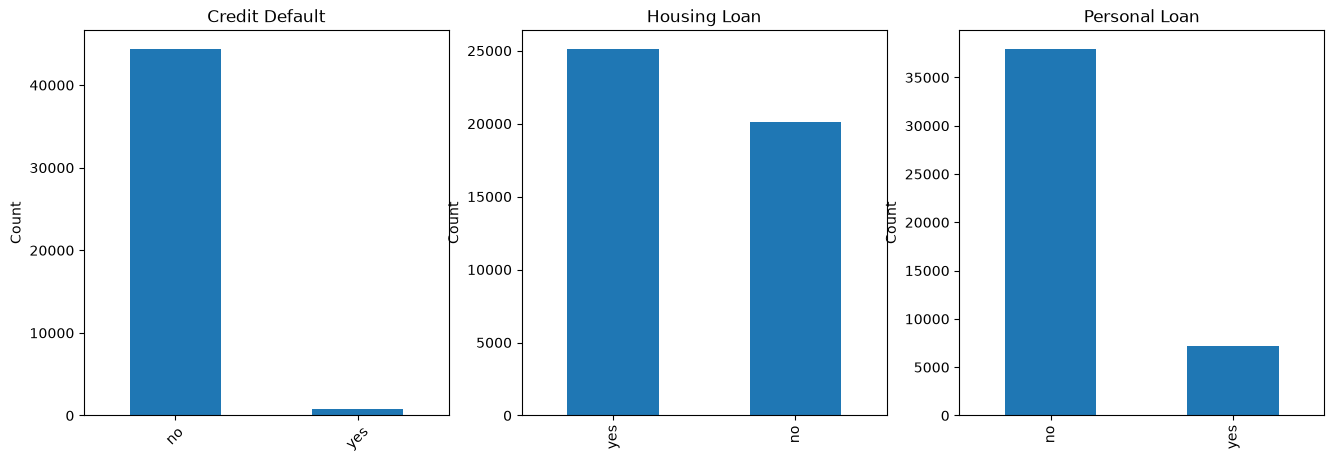

In [78]:
#Check the distribution of credit default, housing loan, and personal loan using bar plots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Credit default
df["credit_default"].value_counts().plot(kind="bar", ax=axes[0])
axes[0].set_title("Credit Default")
axes[0].set_xlabel("")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

# Housing loan
df["housing_loan"].value_counts().plot(
    kind="bar", ax=axes[1]
)
axes[1].set_title("Housing Loan")
axes[1].set_xlabel("")
axes[1].set_ylabel("Count")

# Personal loan
df["personal_loan"].value_counts().plot(
    kind="bar", ax=axes[2]
)
axes[2].set_title("Personal Loan")
axes[2].set_xlabel("")
axes[2].set_ylabel("Count")

plt.ylabel("Count")
plt.show()

Now checking the relations between some of the variable with our target variable.

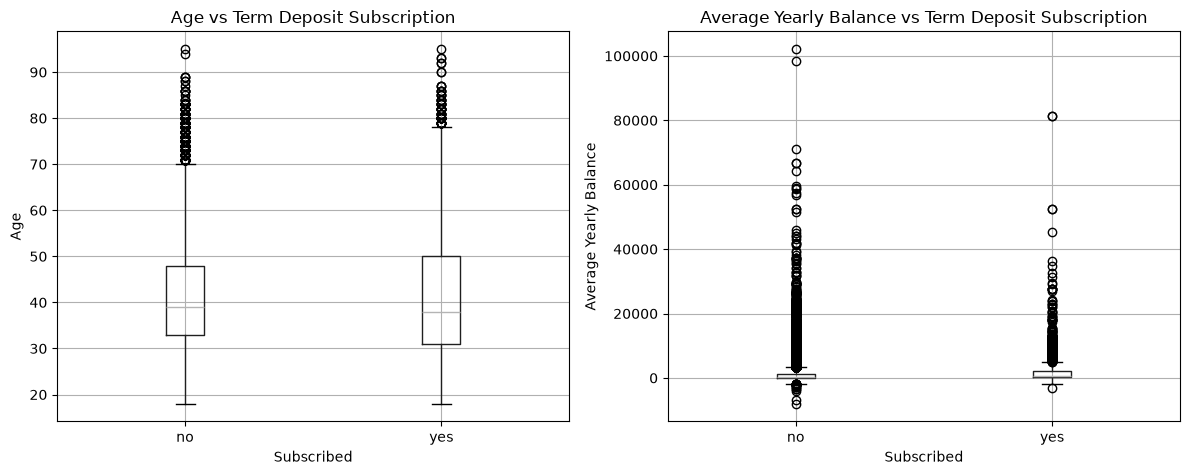

In [79]:
#Starting with some numerical variables, let's see how they relate to our target variable using boxplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Age vs target
df.boxplot(
    column="age",
    by="subscribed_to_term_deposit",
    ax=axes[0]
)
axes[0].set_title("Age vs Term Deposit Subscription")
axes[0].set_xlabel("Subscribed")
axes[0].set_ylabel("Age")

# Average yearly balance vs target
df.boxplot(
    column="average_yearly_balance",
    by="subscribed_to_term_deposit",
    ax=axes[1]
)
axes[1].set_title("Average Yearly Balance vs Term Deposit Subscription")
axes[1].set_xlabel("Subscribed")
axes[1].set_ylabel("Average Yearly Balance")

plt.suptitle("")
plt.tight_layout()
plt.show()

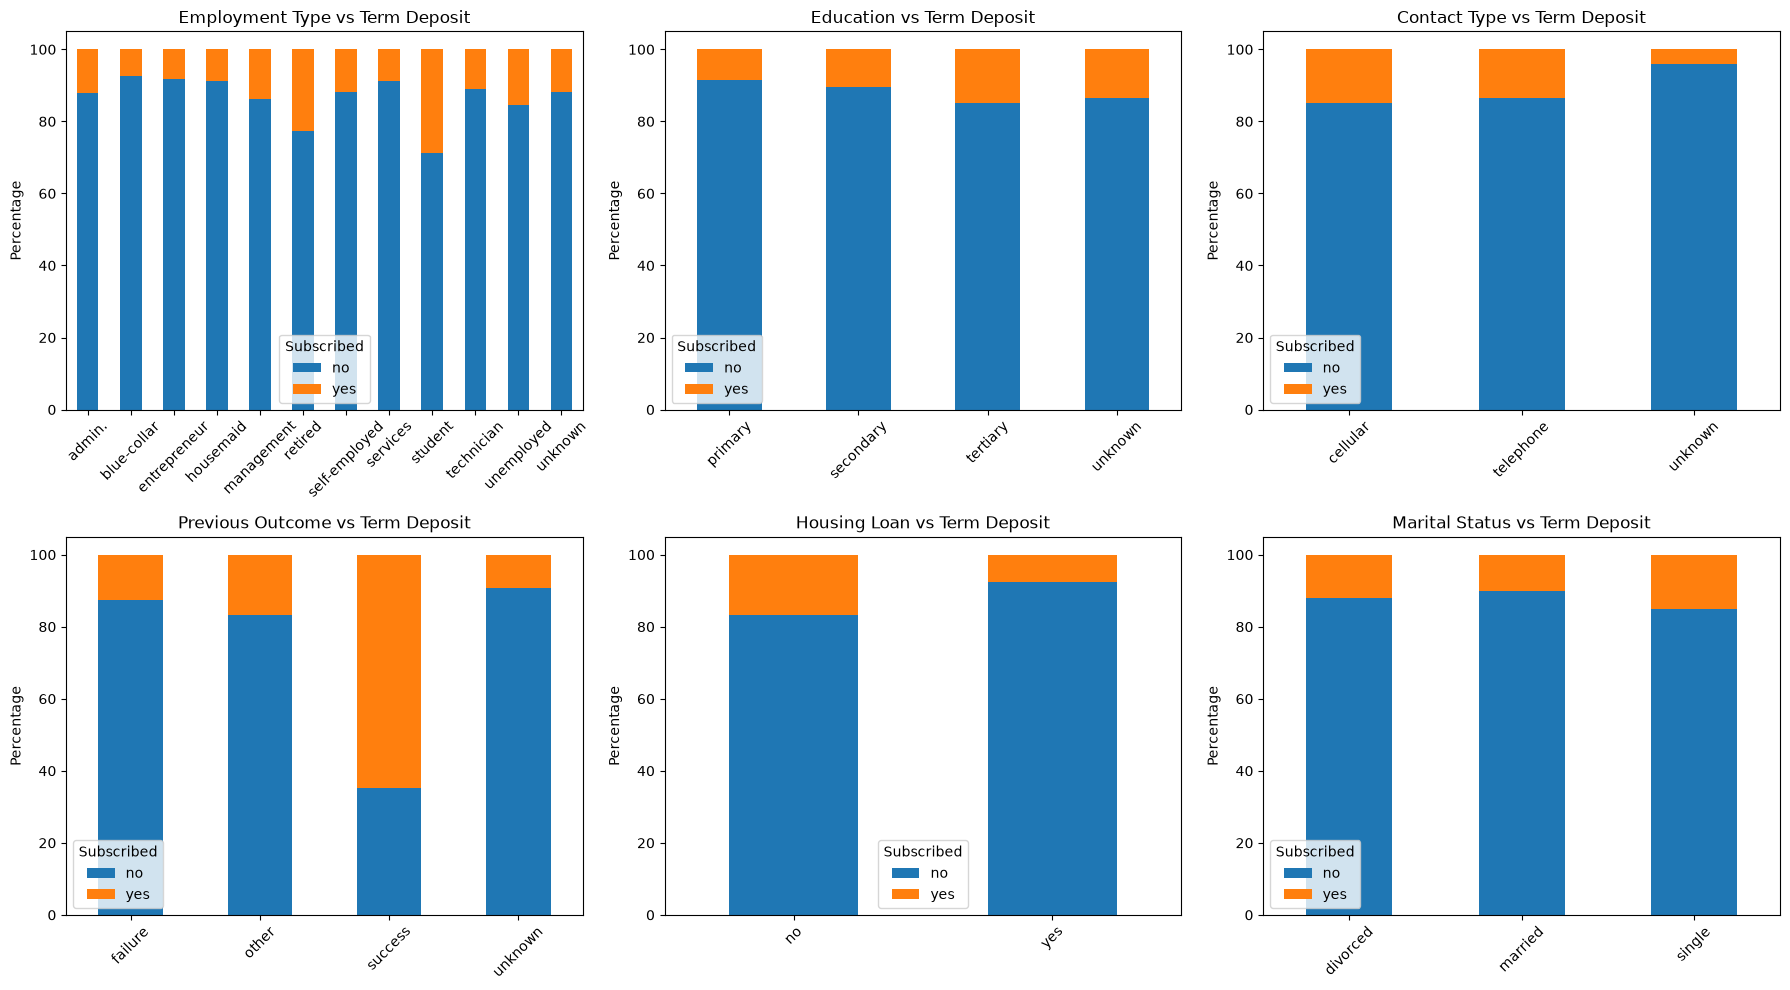

In [17]:
#Then some of the categorical variables, let's see how they relate to our target variable using bar plots
categorical_cols = [
    "employment_type",
    "education",
    "contact_type",
    "previous_outcome",
    "housing_loan",
    "marital_status"
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, col in zip(axes, categorical_cols):
    table = pd.crosstab(
        df[col],
        df["subscribed_to_term_deposit"],
        normalize="index"
    ) * 100

    table.plot(
        kind="bar",
        stacked=True,
        ax=ax
    )

    ax.set_title(f"{col.replace('_', ' ').title()} vs Term Deposit")
    ax.set_xlabel("")
    ax.set_ylabel("Percentage")
    ax.tick_params(axis="x", rotation=45)
    ax.legend(title="Subscribed")

plt.tight_layout()
plt.show()

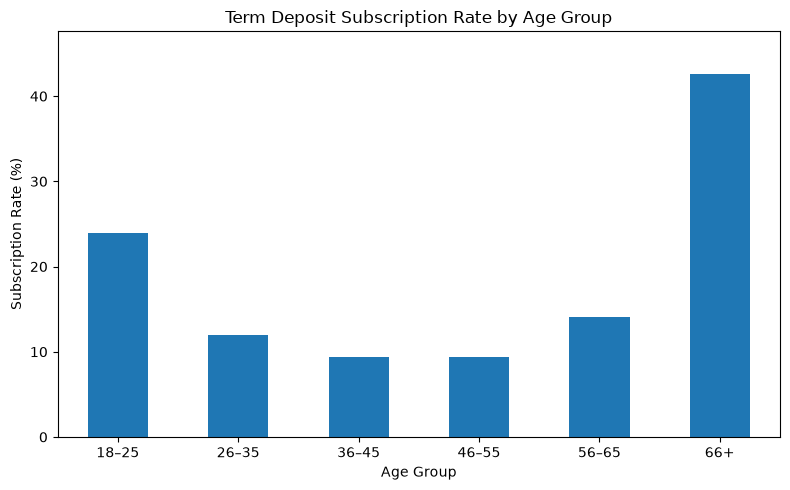

In [80]:
# Create age groups to make it easier to analyze the subscription rate by age group
age_bins = [18, 25, 35, 45, 55, 65, float("inf")]
age_labels = ["18–25", "26–35", "36–45", "46–55", "56–65", "66+"]

df["age_group"] = pd.cut(
    df["age"],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True
)

# Calculate subscription rate
age_subscription = (
    df.groupby("age_group", observed=False)["subscribed_to_term_deposit"]
      .apply(lambda x: (x == "yes").mean() * 100)
)

# Plot
ax = age_subscription.plot(
    kind="bar",
    figsize=(8, 5)
)

ax.set_title("Term Deposit Subscription Rate by Age Group")
ax.set_xlabel("Age Group")
ax.set_ylabel("Subscription Rate (%)")
ax.set_ylim(0, age_subscription.max() + 5)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [81]:
df["average_yearly_balance"].describe()

count     45211.000000
mean       1362.272058
std        3044.765829
min       -8019.000000
25%          72.000000
50%         448.000000
75%        1428.000000
max      102127.000000
Name: average_yearly_balance, dtype: float64

In [82]:
df["days_since_last_campaign_contact"].describe()

count    45211.000000
mean        40.197828
std        100.128746
min         -1.000000
25%         -1.000000
50%         -1.000000
75%         -1.000000
max        871.000000
Name: days_since_last_campaign_contact, dtype: float64

Since from our data in the column, days since last campaign contact we have -1 which makes it hard for the model to predict correctly, we are adding a few columns to help communicate that -1 meeans that the customer was not previously contacted and not that they were contacted -1 days ago. 

In [83]:
df["previously_contacted"] = (
    df["days_since_last_campaign_contact"] != -1
).astype(int)

In [84]:
df["days_since_last_campaign_contact_clean"] = (
    df["days_since_last_campaign_contact"]
    .replace(-1, 0)
)

In [85]:
df[[
    "days_since_last_campaign_contact",
    "previously_contacted",
    "days_since_last_campaign_contact_clean"
]].head(10)

,days_since_last_campaign_contact,previously_contacted,days_since_last_campaign_contact_clean
0,-1,0,0
1,-1,0,0
2,-1,0,0
3,-1,0,0
4,-1,0,0
5,-1,0,0
6,-1,0,0
7,-1,0,0
8,-1,0,0
9,-1,0,0


In [86]:
df["previously_contacted"].value_counts()

previously_contacted
0    36954
1     8257
Name: count, dtype: int64

In [87]:
df.head(10)

,age,employment_type,marital_status,education,credit_default,average_yearly_balance,housing_loan,personal_loan,contact_type,last_contact_day,last_contact_month,last_contact_duration,campaign_contacts,days_since_last_campaign_contact,previous_contacts_before_campaign,previous_outcome,subscribed_to_term_deposit,age_group,previously_contacted,days_since_last_campaign_contact_clean
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no,56–65,0,0
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no,36–45,0,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no,26–35,0,0
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no,46–55,0,0
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no,26–35,0,0
5,35,management,married,tertiary,no,231,yes,no,unknown,5,may,139,1,-1,0,unknown,no,26–35,0,0
6,28,management,single,tertiary,no,447,yes,yes,unknown,5,may,217,1,-1,0,unknown,no,26–35,0,0
7,42,entrepreneur,divorced,tertiary,yes,2,yes,no,unknown,5,may,380,1,-1,0,unknown,no,36–45,0,0
8,58,retired,married,primary,no,121,yes,no,unknown,5,may,50,1,-1,0,unknown,no,56–65,0,0
9,43,technician,single,secondary,no,593,yes,no,unknown,5,may,55,1,-1,0,unknown,no,36–45,0,0


Performing an investigation to see whether the variable "last_contact_duration" may cause data leakage. In the assusmption that this is amount of time that was taken in the last call before the customer subscribed or did not subscribe. As an insitution this is information that they do not have while trying to predict whether to call them and if the marketing technique will work. 

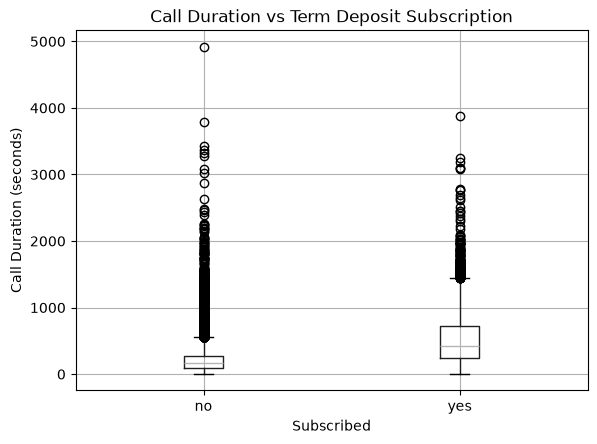

In [88]:
df.boxplot(
    column="last_contact_duration",
    by="subscribed_to_term_deposit"
)

plt.title("Call Duration vs Term Deposit Subscription")
plt.suptitle("")
plt.xlabel("Subscribed")
plt.ylabel("Call Duration (seconds)")
plt.show()

Th graph above proves our assumption right, most the customers whose calls were longer ended up subscribing to the term deposit, therefore this variable may cause data leakage in out model.

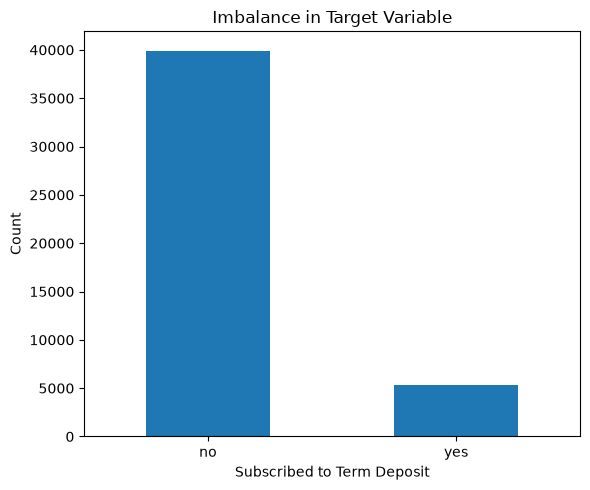

In [89]:
# Check the imbalance in the target variable

plt.figure(figsize=(6, 5))

df["subscribed_to_term_deposit"].value_counts().plot(
    kind="bar"
)

plt.title("Imbalance in Target Variable")
plt.xlabel("Subscribed to Term Deposit")
plt.ylabel("Count")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [90]:
#Checking to see how the contact type relates to whether the customer was previously contacted or not. 
#Especially to see whether the unknown contact type is a result of no previous contact being made

pd.crosstab(
    df["contact_type"],
    df["previously_contacted"],
    normalize="index"
).mul(100).round(2)

previously_contacted,0,1
contact_type,,
cellular,74.20,25.80
telephone,78.29,21.71
unknown,99.46,0.54


In [91]:
df.columns

Index(['age', 'employment_type', 'marital_status', 'education',
       'credit_default', 'average_yearly_balance', 'housing_loan',
       'personal_loan', 'contact_type', 'last_contact_day',
       'last_contact_month', 'last_contact_duration', 'campaign_contacts',
       'days_since_last_campaign_contact', 'previous_contacts_before_campaign',
       'previous_outcome', 'subscribed_to_term_deposit', 'age_group',
       'previously_contacted', 'days_since_last_campaign_contact_clean'],
      dtype='str')

In [92]:
numeric_cols = [
    "age",
    "average_yearly_balance",
    "campaign_contacts",
    "days_since_last_campaign_contact_clean",
    "previous_contacts_before_campaign",
]

In [93]:
df[numeric_cols].head()

,age,average_yearly_balance,campaign_contacts,days_since_last_campaign_contact_clean,previous_contacts_before_campaign
0,58,2143,1,0,0
1,44,29,1,0,0
2,33,2,1,0,0
3,47,1506,1,0,0
4,33,1,1,0,0


In [94]:
correlation_matrix = df[numeric_cols].corr()

correlation_matrix

,age,average_yearly_balance,campaign_contacts,days_since_last_campaign_contact_clean,previous_contacts_before_campaign
age,1.000000,0.097783,0.004760,-0.023841,0.001288
average_yearly_balance,0.097783,1.000000,-0.014578,0.003330,0.016674
campaign_contacts,0.004760,-0.014578,1.000000,-0.088508,-0.032855
days_since_last_campaign_contact_clean,-0.023841,0.003330,-0.088508,1.000000,0.454288
previous_contacts_before_campaign,0.001288,0.016674,-0.032855,0.454288,1.000000


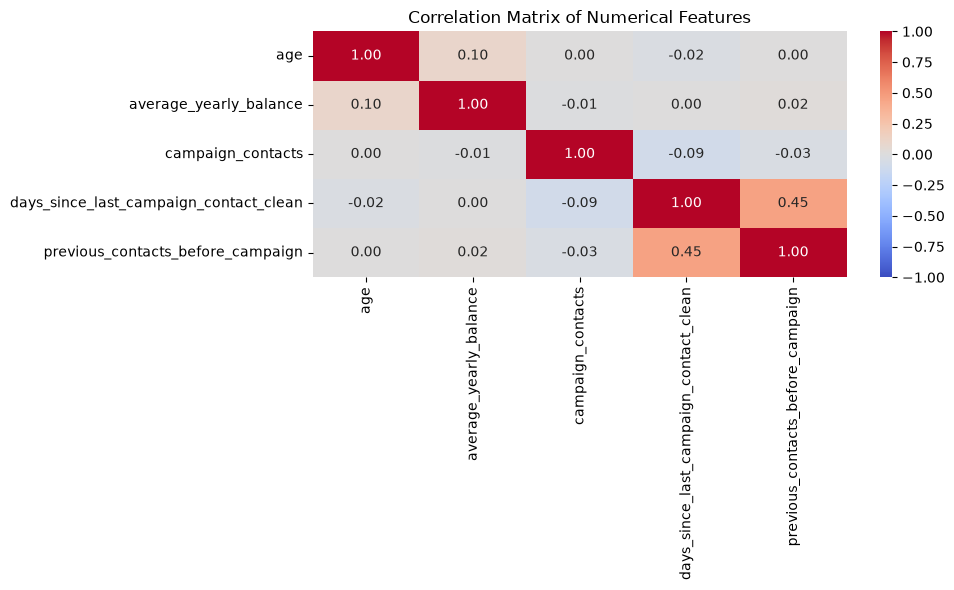

In [95]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

Findings from the EDA
- Target imbalance: The majority of customers did not subscribe to a term deposit, meaning accuracy alone may not be sufficient for evaluating the model.
- Marketing histsory: Most of the customers who had a successful out come in previous marketing campaign subcrided to the term deposit after this campaign.
- To avoid data leakage we will handle the variable "Call duration" keenly.
- On the contact type variable "unkownn" could be assusmed to be those whow were contacted, but seems there are a few outliers we will not maintain that assusmption.
- From the correlation matrix, The most noticeable relationship is: days_since_last_campaign_contact_clean ↔ previous_contacts_before_campaign = 0.45. Which suggest that for customers with more prevous contacts tend to have a higher values for days since their last contact, on average, in a moderately positive linear pattern.

DATA PREPROCESSING

In [ ]:
#Since we have categorical data, we will use One hot encoding, even for binary categorical data, like th housing loan (y/n) and personal loan (y/n). 
#This is because some machine learning algorithms can perform better with one-hot encoded features, and it also allows for easier interpretation of the model's coefficients.

Performing our Train-Test Spilt to avid any leakage.
We will also exlude , last contact duration and campaign contacts since this will happen after the campaign and we are trying to predict the customer that we should call, meaning these two are information that we won't have beforehand.

In [104]:
X = df.drop(columns=[
    "subscribed_to_term_deposit",
    "last_contact_duration",
    "campaign_contacts",
    "last_contact_day",
    "last_contact_month",
    "days_since_last_campaign_contact",
    "age_group"
])

In [105]:
y = df["subscribed_to_term_deposit"]

In [106]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

X shape: (45211, 13)
y shape: (45211,)

Features:
['age', 'employment_type', 'marital_status', 'education', 'credit_default', 'average_yearly_balance', 'housing_loan', 'personal_loan', 'contact_type', 'previous_contacts_before_campaign', 'previous_outcome', 'previously_contacted', 'days_since_last_campaign_contact_clean']

Target:
subscribed_to_term_deposit


In [107]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [112]:
categorical_features = [
    "employment_type",
    "marital_status",
    "education",
    "credit_default",
    "housing_loan",
    "personal_loan",
    "contact_type",
    "previous_outcome",
    "previously_contacted"
]

In [113]:
numerical_features = [
    "age",
    "average_yearly_balance",
    "days_since_last_campaign_contact_clean",
    "previous_contacts_before_campaign"
]

In [114]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 36168 entries, 24001 to 44229
Data columns (total 13 columns):
 #   Column                                  Non-Null Count  Dtype
---  ------                                  --------------  -----
 0   age                                     36168 non-null  int64
 1   employment_type                         36168 non-null  str  
 2   marital_status                          36168 non-null  str  
 3   education                               36168 non-null  str  
 4   credit_default                          36168 non-null  str  
 5   average_yearly_balance                  36168 non-null  int64
 6   housing_loan                            36168 non-null  str  
 7   personal_loan                           36168 non-null  str  
 8   contact_type                            36168 non-null  str  
 9   previous_contacts_before_campaign       36168 non-null  int64
 10  previous_outcome                        36168 non-null  str  
 11  previously_contacted       

In [115]:
X_train.isnull().sum()

age                                       0
employment_type                           0
marital_status                            0
education                                 0
credit_default                            0
average_yearly_balance                    0
housing_loan                              0
personal_loan                             0
contact_type                              0
previous_contacts_before_campaign         0
previous_outcome                          0
previously_contacted                      0
days_since_last_campaign_contact_clean    0
dtype: int64

In [116]:
print("Numerical columns:")
print(X_train[numerical_features].dtypes)

print("\nCategorical columns:")
print(X_train[categorical_features].dtypes)

Numerical columns:
age                                       int64
average_yearly_balance                    int64
days_since_last_campaign_contact_clean    int64
previous_contacts_before_campaign         int64
dtype: object

Categorical columns:
employment_type           str
marital_status            str
education                 str
credit_default            str
housing_loan              str
personal_loan             str
contact_type              str
previous_outcome          str
previously_contacted    int64
dtype: object


In [118]:
#Preprocessing pipeline for numerical and OHE for categorical features
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [120]:
#Baseline Regression pipeline using Logistic Regression and class weights to handle class imbalance
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=42
        ))
    ]
)
logistic_pipeline.fit(X_train, y_train)
y_pred = logistic_pipeline.predict(X_test)
y_pred_proba = logistic_pipeline.predict_proba(X_test)[:, 1]

In [121]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          no       0.94      0.69      0.80      7985
         yes       0.22      0.66      0.33      1058

    accuracy                           0.69      9043
   macro avg       0.58      0.67      0.56      9043
weighted avg       0.85      0.69      0.74      9043



In [122]:
#Attempting a Random Forest Classifier to see if it performs better than Logistic Regression
#Since it does not need the scaling of features, we can use the original features without scaling. However, we will still use one-hot encoding for categorical features.
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

rf_preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [123]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", rf_preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=100,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]
)
rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)

y_pred_proba_rf = rf_pipeline.predict_proba(X_test)[:, 1]

In [124]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

          no       0.91      0.90      0.91      7985
         yes       0.32      0.35      0.34      1058

    accuracy                           0.84      9043
   macro avg       0.62      0.63      0.62      9043
weighted avg       0.84      0.84      0.84      9043



In [137]:
y_test_binary = y_test.map({"no": 0, "yes": 1})

In [138]:
#Lets evaluate the two modelsusing ROC-AUC and especially Precision-Recall AUC. This will give us a better overall comparison than looking at one classification report
from sklearn.metrics import roc_auc_score, average_precision_score

# Logistic Regression
logistic_roc_auc = roc_auc_score(y_test_binary, y_pred_proba)
logistic_pr_auc = average_precision_score(y_test_binary, y_pred_proba)

# Random Forest
rf_roc_auc = roc_auc_score(y_test_binary, y_pred_proba_rf)
rf_pr_auc = average_precision_score(y_test_binary, y_pred_proba_rf)

print("Logistic Regression")
print("ROC-AUC:", logistic_roc_auc)
print("PR-AUC:", logistic_pr_auc)

print("\nRandom Forest")
print("ROC-AUC:", rf_roc_auc)
print("PR-AUC:", rf_pr_auc)

Logistic Regression
ROC-AUC: 0.7427557932939005
PR-AUC: 0.3555049549342832

Random Forest
ROC-AUC: 0.7049655959366156
PR-AUC: 0.28734285846082264


In [139]:
#Testing an AdaBoost Classifier to see if it performs better than Logistic Regression and Random Forest
from sklearn.ensemble import AdaBoostClassifier
from sklearn.pipeline import Pipeline

adaboost_pipeline = Pipeline(
    steps=[
        ("preprocessor", rf_preprocessor),
        ("model", AdaBoostClassifier(
            n_estimators=100,
            random_state=42
        ))
    ]
)
adaboost_pipeline.fit(X_train, y_train)

y_pred_ada = adaboost_pipeline.predict(X_test)

y_pred_proba_ada = adaboost_pipeline.predict_proba(X_test)[:, 1]

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_ada))

              precision    recall  f1-score   support

          no       0.90      0.99      0.94      7985
         yes       0.66      0.17      0.27      1058

    accuracy                           0.89      9043
   macro avg       0.78      0.58      0.61      9043
weighted avg       0.87      0.89      0.86      9043



In [140]:
from sklearn.metrics import roc_auc_score, average_precision_score

ada_roc_auc = roc_auc_score(y_test_binary, y_pred_proba_ada)
ada_pr_auc = average_precision_score(y_test_binary, y_pred_proba_ada)

print("AdaBoost ROC-AUC:", ada_roc_auc)
print("AdaBoost PR-AUC:", ada_pr_auc)

AdaBoost ROC-AUC: 0.754514667743039
AdaBoost PR-AUC: 0.37803243938533443


In [145]:
y_train_xgb = y_train.map({"no": 0, "yes": 1})
y_test_xgb = y_test.map({"no": 0, "yes": 1})

In [149]:
#Testing XGBoost Classifier to see if it performs better than Logistic Regression, Random Forest, and AdaBoost
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

# Preprocessing
xgb_preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# XGBoost model
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

# Pipeline
xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", xgb_preprocessor),
        ("classifier", xgb_model)
    ]
)

# Train
xgb_pipeline.fit(X_train, y_train_xgb)

# Predictions
y_pred_xgb = xgb_pipeline.predict(X_test)
y_prob_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]

# Evaluation
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    average_precision_score
)

print(classification_report(y_test_xgb, y_pred_xgb))

print("XGBoost ROC-AUC:", roc_auc_score(y_test_xgb, y_prob_xgb))

print("XGBoost PR-AUC:", average_precision_score(y_test_xgb, y_prob_xgb))

              precision    recall  f1-score   support

           0       0.90      0.98      0.94      7985
           1       0.60      0.19      0.29      1058

    accuracy                           0.89      9043
   macro avg       0.75      0.59      0.61      9043
weighted avg       0.87      0.89      0.86      9043

XGBoost ROC-AUC: 0.7398890642071085
XGBoost PR-AUC: 0.37582323873880985


In [151]:
from sklearn.model_selection import train_test_split

X_fit, X_val, y_fit, y_val = train_test_split(
    X_train,
    y_train_xgb,
    test_size=0.2,
    random_state=42,
    stratify=y_train_xgb
)

In [153]:
from sklearn.base import clone

xgb_threshold_model = clone(xgb_pipeline)

xgb_threshold_model.fit(X_fit, y_fit)

y_val_prob = xgb_threshold_model.predict_proba(X_val)[:, 1]

In [154]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]

results = []

for threshold in thresholds:

    y_val_pred = (y_val_prob >= threshold).astype(int)

    results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_val, y_val_pred, zero_division=0
        ),
        "Recall": recall_score(
            y_val, y_val_pred, zero_division=0
        ),
        "F1-score": f1_score(
            y_val, y_val_pred, zero_division=0
        )
    })

threshold_results = pd.DataFrame(results)

threshold_results.round(3)

,Threshold,Precision,Recall,F1-score
0,0.1,0.227,0.665,0.338
1,0.2,0.376,0.416,0.395
2,0.3,0.488,0.320,0.387
3,0.4,0.564,0.257,0.353
4,0.5,0.634,0.207,0.312


In [155]:
from sklearn.metrics import confusion_matrix
import pandas as pd

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]

results = []

for threshold in thresholds:

    y_val_pred = (y_val_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_val, y_val_pred, labels=[0, 1]
    ).ravel()

    results.append({
        "Threshold": threshold,
        "Customers Selected": tp + fp,
        "Actual Subscribers Found": tp,
        "False Positives": fp,
        "Missed Subscribers": fn
    })

threshold_business_results = pd.DataFrame(results)

threshold_business_results

,Threshold,Customers Selected,Actual Subscribers Found,False Positives,Missed Subscribers
0,0.1,2485,563,1922,283
1,0.2,935,352,583,494
2,0.3,555,271,284,575
3,0.4,385,217,168,629
4,0.5,276,175,101,671


Hyperparameter tuning.

We should improve the model's probability-ranking performance before making a final threshold decision.

For the project we are setting the banks goal to be to identify a meaningful number of potential subscribers without generating too many unnecessary calls.

For this objective, we'll focus on:

Precision: How many selected customers actually subscribe?
Recall: How many actual subscribers we identify?
F1-score: A useful starting point for balancing precision and recall.
PR-AUC: How well the model ranks positive cases across different thresholds.
We'll use F1-score as a tuning reference, while keeping PR-AUC and the actual calling volume in view. We won't assume that maximizing F1 alone guarantees the best business outcome.

In [157]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# Hyperparameter search space
param_dist = {
    "classifier__n_estimators": randint(100, 401),
    "classifier__max_depth": randint(2, 8),
    "classifier__learning_rate": uniform(0.01, 0.19),
    "classifier__min_child_weight": randint(1, 10),
    "classifier__subsample": uniform(0.6, 0.4),
    "classifier__colsample_bytree": uniform(0.6, 0.4)
}

# Randomized search
xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_dist,
    n_iter=15,
    scoring="average_precision",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Fit using only the fitting subset
xgb_search.fit(X_fit, y_fit)

print("Best parameters:")
print(xgb_search.best_params_)

print(
    "Best CV PR-AUC:",
    xgb_search.best_score_
)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best parameters:
{'classifier__colsample_bytree': np.float64(0.7783331011414365), 'classifier__learning_rate': np.float64(0.028995234005420548), 'classifier__max_depth': 4, 'classifier__min_child_weight': 8, 'classifier__n_estimators': 199, 'classifier__subsample': np.float64(0.6571467271687763)}
Best CV PR-AUC: 0.3879486448660569


In [158]:
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score
)

best_xgb = xgb_search.best_estimator_

y_val_prob_tuned = best_xgb.predict_proba(X_val)[:, 1]

print(
    "Tuned XGBoost PR-AUC:",
    average_precision_score(y_val, y_val_prob_tuned)
)

print(
    "Tuned XGBoost ROC-AUC:",
    roc_auc_score(y_val, y_val_prob_tuned)
)

Tuned XGBoost PR-AUC: 0.41818718212018274
Tuned XGBoost ROC-AUC: 0.7737064435236873


In [159]:
print(
    "Baseline validation PR-AUC:",
    average_precision_score(y_val, y_val_prob)
)

print(
    "Tuned validation PR-AUC:",
    average_precision_score(y_val, y_val_prob_tuned)
)

Baseline validation PR-AUC: 0.3852853097208406
Tuned validation PR-AUC: 0.41818718212018274


In [160]:
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]

threshold_results = []

for threshold in thresholds:
    y_val_pred = (y_val_prob_tuned >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_val, y_val_pred),
        "Recall": recall_score(y_val, y_val_pred),
        "F1": f1_score(y_val, y_val_pred),
        "Predicted Calls": y_val_pred.sum(),
        "Actual Subscribers Found": (
            (y_val == 1) & (y_val_pred == 1)
        ).sum(),
        "Unnecessary Calls": (
            (y_val == 0) & (y_val_pred == 1)
        ).sum(),
        "Missed Subscribers": (
            (y_val == 1) & (y_val_pred == 0)
        ).sum()
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df.round(3)

,Threshold,Precision,Recall,F1,Predicted Calls,Actual Subscribers Found,Unnecessary Calls,Missed Subscribers
0,0.1,0.230,0.722,0.348,2661,611,2050,235
1,0.2,0.444,0.418,0.431,797,354,443,492
2,0.3,0.553,0.333,0.416,510,282,228,564
3,0.4,0.643,0.221,0.329,291,187,104,659
4,0.5,0.704,0.165,0.268,199,140,59,706


In [161]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    average_precision_score,
    roc_auc_score
)

# Refit the selected model on the full training set
final_xgb = xgb_search.best_estimator_
final_xgb.fit(X_train, y_train_xgb)

# Predict probabilities on the test set
y_test_prob = final_xgb.predict_proba(X_test)[:, 1]

# Apply the provisional threshold
chosen_threshold = 0.2
y_test_pred = (y_test_prob >= chosen_threshold).astype(int)

# Evaluate
print(classification_report(y_test_xgb, y_test_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test_xgb, y_test_pred))

print("Test PR-AUC:", average_precision_score(
    y_test_xgb, y_test_prob
))

print("Test ROC-AUC:", roc_auc_score(
    y_test_xgb, y_test_prob
))

              precision    recall  f1-score   support

           0       0.92      0.93      0.92      7985
           1       0.43      0.41      0.42      1058

    accuracy                           0.87      9043
   macro avg       0.67      0.67      0.67      9043
weighted avg       0.86      0.87      0.87      9043

Confusion Matrix:
[[7402  583]
 [ 626  432]]
Test PR-AUC: 0.39960232188919
Test ROC-AUC: 0.761793970973458


The tuned XGBoost model achieved a test PR-AUC of 0.400. At a classification threshold of 0.2, it achieved 43% precision and 41% recall for term-deposit subscribers. On the 9,043-customer test set, it identified 432 subscribers while selecting 583 non-subscribers and missing 626 actual subscribers. These results illustrate the trade-off between identifying potential subscribers and limiting unnecessary campaign calls.

FEATURE IMPORTANCE

In [162]:
# Get the fitted preprocessing step and XGBoost model
preprocessor = final_xgb.named_steps["preprocessor"]
model = final_xgb.named_steps["classifier"]

# Get feature names after one-hot encoding
feature_names = preprocessor.get_feature_names_out()

# Get XGBoost feature importance scores
importance_scores = model.feature_importances_

# Create a DataFrame
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_scores
})

# Sort from most to least important
feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

# Display the top 15 features
feature_importance_df.head(15)

,Feature,Importance
34,cat__previous_outcome_success,0.341756
31,cat__contact_type_unknown,0.121449
25,cat__housing_loan_no,0.065116
29,cat__contact_type_cellular,0.040514
26,cat__housing_loan_yes,0.030567
32,cat__previous_outcome_failure,0.029934
33,cat__previous_outcome_other,0.027925
12,cat__employment_type_student,0.027422
18,cat__marital_status_single,0.024429
0,num__age,0.024353


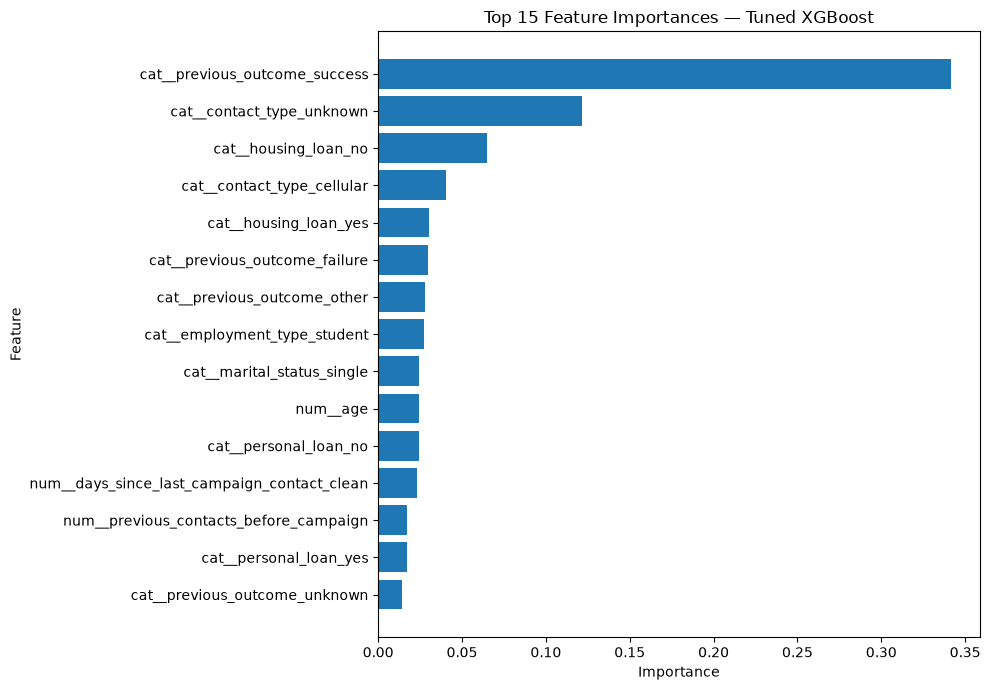

In [163]:
top_features = feature_importance_df.head(15).sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 15 Feature Importances — Tuned XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [164]:
# Original categorical feature names
categorical_names = categorical_features

def get_original_feature(encoded_feature):
    # Numerical features
    if encoded_feature.startswith("num__"):
        return encoded_feature.replace("num__", "", 1)

    # Categorical features
    if encoded_feature.startswith("cat__"):
        feature = encoded_feature.replace("cat__", "", 1)

        # Match the original column name
        for col in sorted(categorical_names, key=len, reverse=True):
            if feature.startswith(col + "_"):
                return col

    return encoded_feature

# Add original feature name
feature_importance_df["Original_Feature"] = (
    feature_importance_df["Feature"].apply(get_original_feature)
)

# Combine the importance scores by original feature
grouped_importance = (
    feature_importance_df
    .groupby("Original_Feature", as_index=False)["Importance"]
    .sum()
    .sort_values("Importance", ascending=False)
)

grouped_importance

,Original_Feature,Importance
11,previous_outcome,0.414008
2,contact_type,0.173394
6,employment_type,0.112288
7,housing_loan,0.095684
8,marital_status,0.045329
9,personal_loan,0.041466
5,education,0.030897
0,age,0.024353
4,days_since_last_campaign_contact_clean,0.022954
10,previous_contacts_before_campaign,0.017473


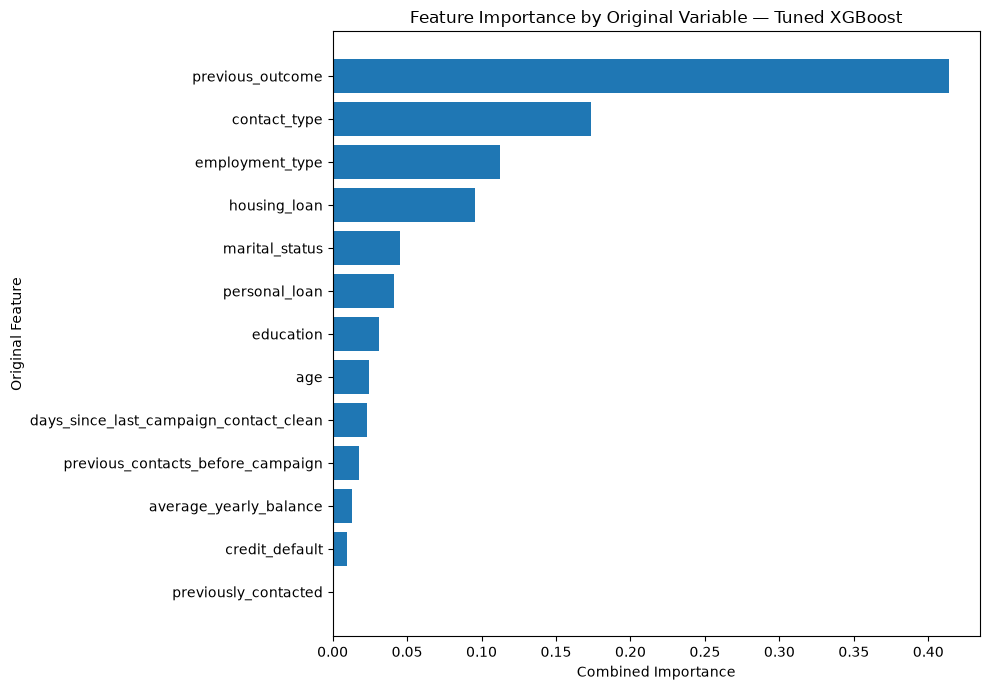

In [165]:
top_grouped = grouped_importance.sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_grouped["Original_Feature"],
    top_grouped["Importance"]
)

plt.title("Feature Importance by Original Variable — Tuned XGBoost")
plt.xlabel("Combined Importance")
plt.ylabel("Original Feature")
plt.tight_layout()
plt.show()

EXPLAINABIILITY

c:\Users\Tech\Documents\Bank Marketing\capstone\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


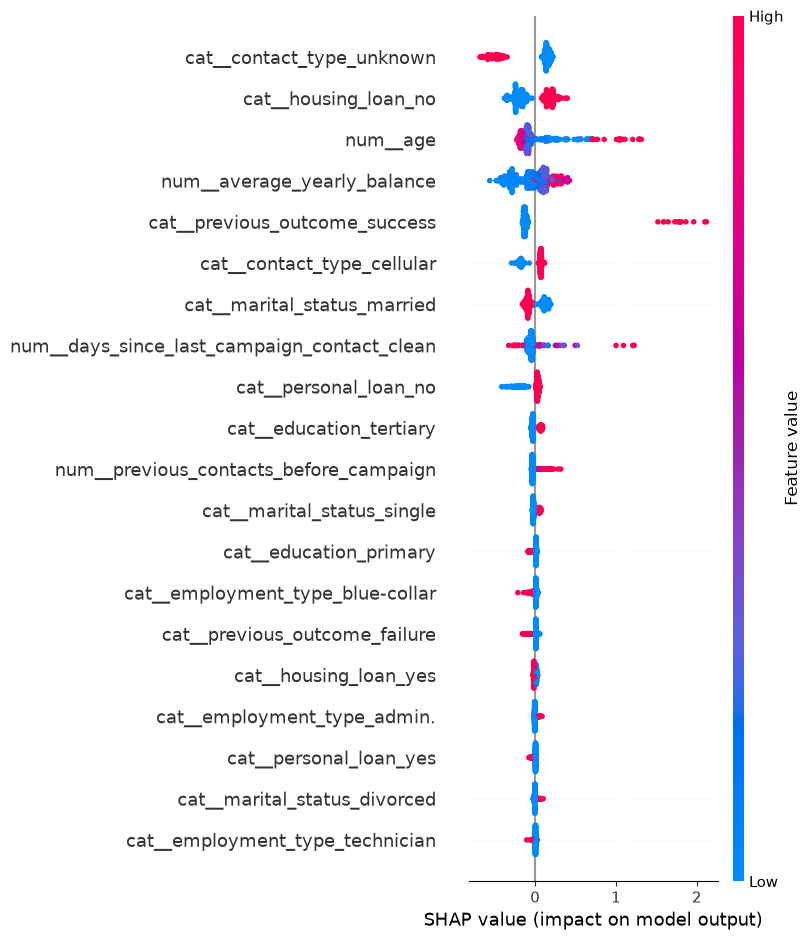

In [166]:
import shap

# Use a sample of training data for explainability
X_shap = X_train.sample(
    n=min(500, len(X_train)),
    random_state=42
)

# Transform the sample using the fitted preprocessor
X_shap_transformed = (
    final_xgb.named_steps["preprocessor"]
    .transform(X_shap)
)

# Get the encoded feature names
feature_names = (
    final_xgb.named_steps["preprocessor"]
    .get_feature_names_out()
)

# Explain the fitted XGBoost model
explainer = shap.TreeExplainer(
    final_xgb.named_steps["classifier"]
)

shap_values = explainer(
    X_shap_transformed
)

# Summary plot
shap.summary_plot(
    shap_values.values,
    X_shap_transformed,
    feature_names=feature_names
)

In [168]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test_xgb, y_test_prob)

print("Test ROC-AUC:", roc_auc)

Test ROC-AUC: 0.761793970973458
